In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
iris = load_iris()

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nNumber of Samples:")
print(len(iris.data))

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Number of Samples:
150


In [ ]:

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


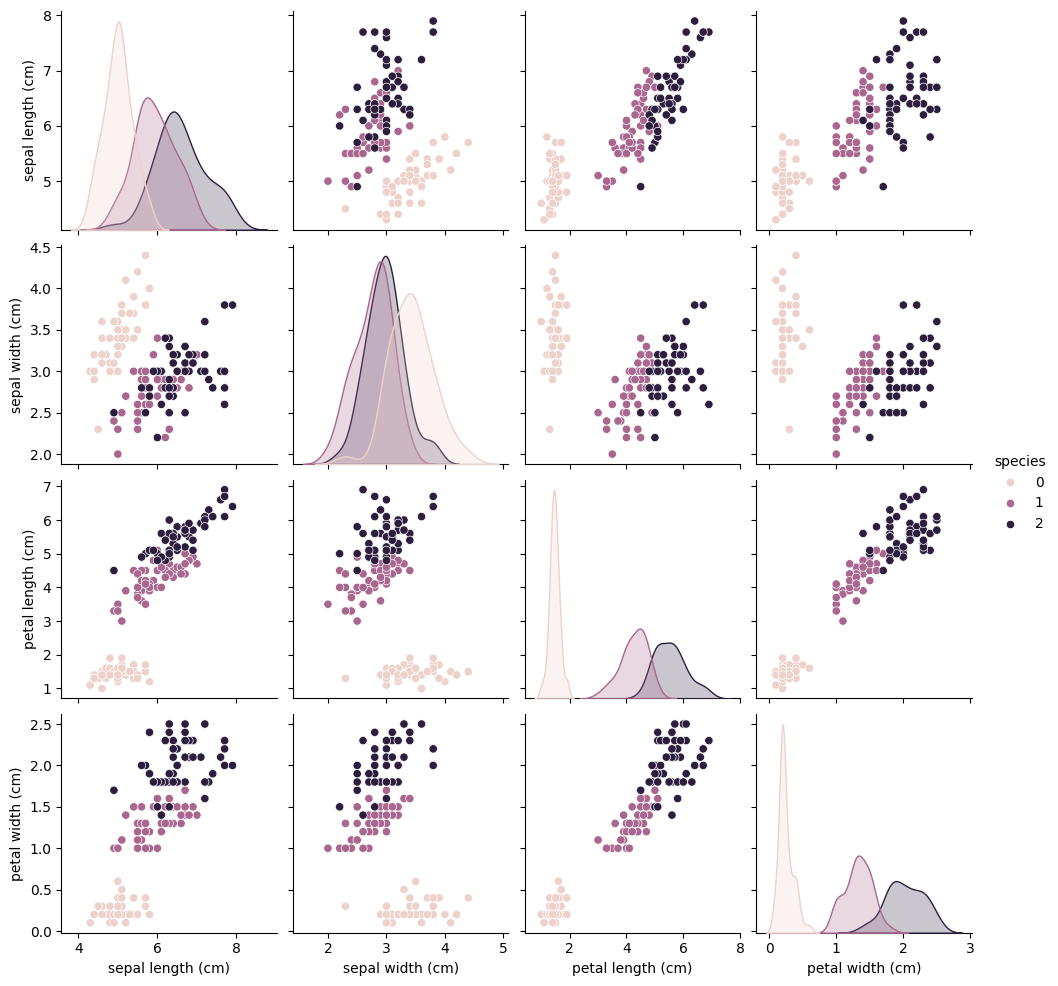

In [ ]:
sns.pairplot(df, hue='species')
plt.show()

In [ ]:
df['species'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


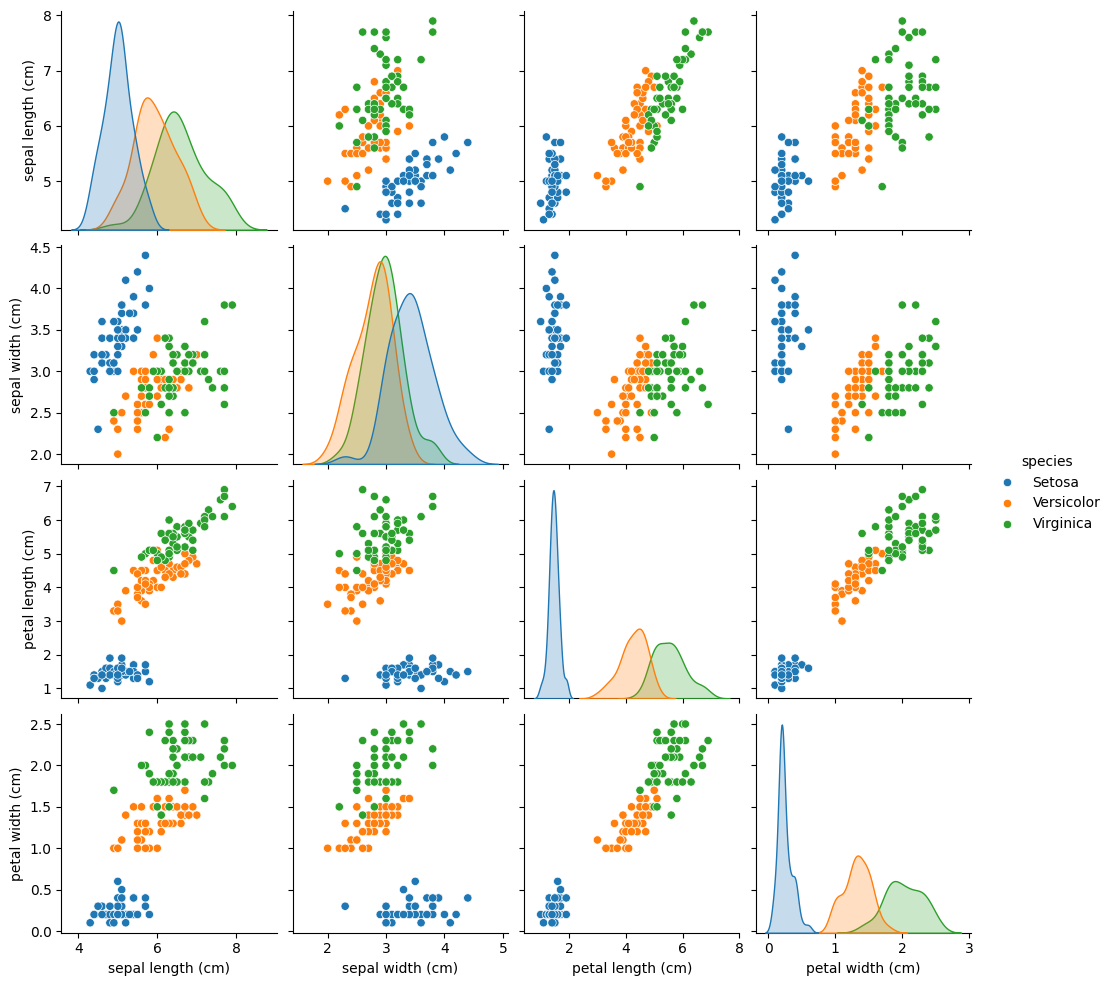

In [ ]:
sns.pairplot(df, hue='species')
plt.show()

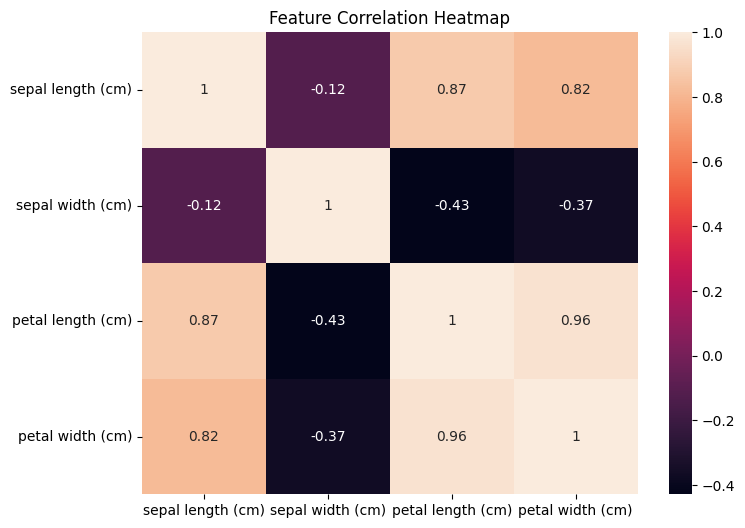

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop('species', axis=1)
y = df['species']

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

print(predictions[:10])

['Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa'
 'Versicolor' 'Virginica' 'Versicolor' 'Versicolor']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


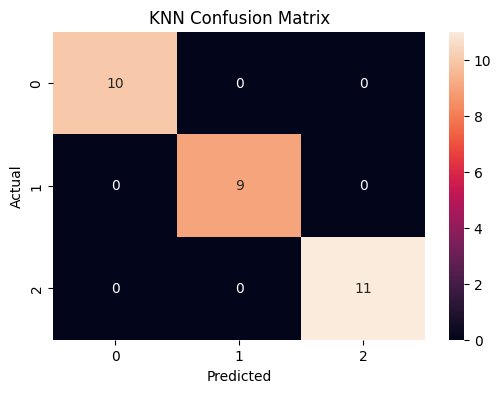

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

from sklearn.metrics import accuracy_score

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_pred)
)

Decision Tree Accuracy: 1.0


In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, svm_pred)
)

SVM Accuracy: 1.0


In [ ]:
results = {
    "KNN": accuracy_score(y_test, predictions),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "SVM": accuracy_score(y_test, svm_pred)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

KNN: 1.0000
Decision Tree: 1.0000
SVM: 1.0000
